# Assignment 04 · Miền `customer_comments` — Notebook 03
# Mạng tích chập một chiều hiện thực bằng **TensorFlow / Keras**

- **Sinh viên:** Nguyễn Duy Nghĩa · **Mã sinh viên:** B23DCCN600 · **Lớp:** D23CTPM01
- **Học phần:** Phát triển các Hệ thống Thông minh · **Giảng viên:** PGS.TS Trần Đình Quế
- **Học kỳ:** Học kỳ 1 năm học 2026 – 2027
- **Assignment 04:** Convolutional Neural Networks — From Mathematical Convolution to NumPy, PyTorch and TensorFlow
- **Miền dữ liệu:** `customer_comments` — bình luận đánh giá sản phẩm thời trang nữ (Women's E-Commerce Clothing Reviews)

---

## 1. Mục tiêu của notebook

Đây là cách hiện thực thứ ba và cũng là cách trừu tượng hóa cao nhất trong ba cách. Nếu notebook 01
yêu cầu viết tay từng đạo hàm và notebook 02 yêu cầu viết tay vòng lặp huấn luyện, thì Keras thu gọn
toàn bộ phần đó vào một lời gọi `model.fit(...)`. Mục tiêu của notebook là:

1. Tái hiện **chính xác cùng một kiến trúc** bằng `keras.layers.Embedding / Conv1D /
   GlobalMaxPooling1D / Dense`.
2. Chỉ rõ những chỗ Keras **khác** PyTorch về quy ước, đặc biệt là bố cục tensor và cách xử lý token
   đệm, để không nhầm lẫn khi đọc chéo mã nguồn giữa hai thư viện.
3. Cung cấp điểm dữ liệu thứ ba cho bảng so sánh ba cách hiện thực ở notebook 01.

### Kiến trúc (giữ nguyên theo `CONTRACT.md`, Mục 4)

$$
\text{tokens}(50) \;\to\; \text{Embedding}(5000, 100) \;\to\; \text{Conv1D}(32, K{=}3) \;\to\;
\text{ReLU} \;\to\; \text{GlobalMaxPool1D} \;\to\; \text{Dense}(1) \;\to\; \sigma
$$

### Hai khác biệt quy ước quan trọng so với PyTorch

| Vấn đề | PyTorch | TensorFlow / Keras |
|---|---|---|
| Bố cục tensor của Conv1D | `(batch, kênh, độ dài)`, cần `transpose(1,2)` sau Embedding | `(batch, độ dài, kênh)` — **khớp thẳng** với đầu ra của Embedding, không cần hoán vị |
| Token đệm | `nn.Embedding(..., padding_idx=0)` khóa hàng `<PAD>` bằng 0 và chặn gradient | không có tham số tương đương; hàng `<PAD>` vẫn được cập nhật như mọi hàng khác |

Khác biệt thứ hai là một sai lệch nhỏ **có thật** giữa ba cách hiện thực và được ghi rõ trong khóa
`notes` của tệp metrics. Ảnh hưởng thực tế của nó bị giới hạn: sau tầng `GlobalMaxPooling1D`, chỉ vị
trí có giá trị kích hoạt lớn nhất mới đi tiếp, nên một vector `<PAD>` lệch khỏi 0 chỉ gây tác động
khi nó tình cờ tạo ra kích hoạt vượt mọi từ thật trong cùng bình luận.

## 2. Nhập thư viện và cố định seed

In [1]:
import os, re, json, time, math, collections
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

plt.rcParams["font.sans-serif"] = ["Segoe UI", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

VOCAB_SIZE, MAX_LEN, EMBED_DIM = 5000, 50, 100
N_FILTERS, KERNEL = 32, 3
DATA_PATH  = "../data/womens_ecommerce_reviews.csv"
FIG_DIR    = "../reports/figures"
REPORT_DIR = "../reports"
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(REPORT_DIR, exist_ok=True)

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("Thiết bị   :", [d.device_type for d in tf.config.list_physical_devices()])
print("Seed       :", RANDOM_SEED)

TensorFlow : 2.21.0
Keras      : 3.15.1


Thiết bị   : ['CPU']
Seed       : 42


## 3. Nạp dữ liệu và tiền xử lý

Quy trình tiền xử lý được lặp lại nguyên văn từ notebook 01 để ba notebook nhìn thấy cùng một ma
trận chỉ số và cùng một phép chia tập. Mọi bước đều tất định với `random_state=42`.

### 3.1 Quy trình tiền xử lý bắt buộc

Hợp đồng tích hợp (`CONTRACT.md`, Mục 3) quy định quy trình tiền xử lý **bắt buộc** cho miền
`customer_comments`, và báo cáo tuân thủ nguyên văn:

1. `dropna(subset=['Review Text','Recommended IND'])`: loại các bản ghi thiếu nội dung hoặc thiếu nhãn.
2. Hạ toàn bộ văn bản về chữ thường.
3. Tách token bằng biểu thức chính quy `re.findall(r'[a-zA-Z]+', text)`.
4. Từ điển kích thước `VOCAB_SIZE = 5000` với hai token đặc biệt `<PAD>` = 0 và `<UNK>` = 1.
5. Cắt hoặc đệm mọi chuỗi về độ dài cố định `MAX_LEN = 50`.
6. Chiều không gian nhúng `EMBED_DIM = 100`.

**Tại sao lại làm như vậy?** Báo cáo giải thích từng lựa chọn thay vì chỉ liệt kê thao tác:

- *Hạ chữ thường và chỉ giữ ký tự chữ cái.* Mục tiêu của bài toán là phân loại quan điểm, không phải
  phân tích chính tả. Nếu giữ nguyên dạng chữ thì `"Love"`, `"love"` và `"LOVE"` bị coi là ba token
  khác nhau, làm phân mảnh vô ích ngân sách 5 000 từ vựng. Biểu thức `[a-zA-Z]+` đồng thời loại bỏ
  chữ số, dấu câu và emoji, vốn là những thành phần mang rất ít thông tin quan điểm trong tập dữ liệu này
  nhưng lại chiếm chỗ trong từ điển.
- *Giới hạn từ điển ở 5 000 từ.* Ma trận nhúng có kích thước $|V| \times d$. Với $d = 100$, mỗi
  1 000 từ tăng thêm tương ứng 100 000 tham số. Giới hạn 5 000 giữ mô hình ở mức nửa triệu tham số,
  vừa đủ nhỏ để huấn luyện bằng NumPy thuần trên CPU trong ngân sách thời gian cho phép. Các từ
  hiếm rơi vào `<UNK>`; đây là hành vi mong muốn vì từ xuất hiện một hai lần không đủ dữ liệu để
  học được một vector nhúng có ý nghĩa.
- *Từ điển chỉ được xây trên tập huấn luyện.* Đây là điểm mấu chốt về tính trung thực của phép đánh
  giá. Nếu đếm tần suất trên toàn bộ dữ liệu, thông tin từ tập kiểm tra sẽ rò rỉ ngược vào giai đoạn
  thiết kế mô hình (data leakage) và chỉ số cuối cùng sẽ lạc quan hơn thực tế.
- *Đệm về độ dài cố định 50.* Phép tích chập một chiều được vector hóa theo lô đòi hỏi mọi mẫu trong
  lô có cùng độ dài. Token `<PAD>` = 0 được gán vector nhúng khởi tạo bằng 0 và **gradient của nó
  luôn bị ép về 0** sau mỗi bước, nên phần đệm không đóng góp tín hiệu học.


In [2]:
df_raw = pd.read_csv(DATA_PATH)
N_RAW = len(df_raw)
df = df_raw.dropna(subset=["Review Text", "Recommended IND"]).reset_index(drop=True)
N_CLEAN = len(df)
labels = df["Recommended IND"].astype(int).values

def tokenize(text: str):
    return re.findall(r"[a-zA-Z]+", text.lower())

tokens_all  = [tokenize(t) for t in df["Review Text"].astype(str)]
doc_lengths = np.array([len(t) for t in tokens_all])

idx_all = np.arange(N_CLEAN)
idx_tmp, idx_test = train_test_split(idx_all, test_size=0.15,
                                     stratify=labels, random_state=RANDOM_SEED)
idx_train, idx_val = train_test_split(idx_tmp, test_size=0.1765,
                                      stratify=labels[idx_tmp], random_state=RANDOM_SEED)
N_TRAIN, N_VAL, N_TEST = len(idx_train), len(idx_val), len(idx_test)

counter = collections.Counter(w for i in idx_train for w in tokens_all[i])
word2id = {"<PAD>": 0, "<UNK>": 1}
for w, _ in counter.most_common(VOCAB_SIZE - 2):
    word2id[w] = len(word2id)

def encode(token_list):
    X = np.zeros((len(token_list), MAX_LEN), dtype=np.int32)
    for i, toks in enumerate(token_list):
        ids = [word2id.get(w, 1) for w in toks[:MAX_LEN]]
        X[i, :len(ids)] = ids
    return X

X_train = encode([tokens_all[i] for i in idx_train])
X_val   = encode([tokens_all[i] for i in idx_val])
X_test  = encode([tokens_all[i] for i in idx_test])
y_train = labels[idx_train].astype(np.float32)
y_val   = labels[idx_val].astype(np.float32)
y_test  = labels[idx_test].astype(np.float32)

print(f"Bản ghi gốc            : {N_RAW:,}")
print(f"Bản ghi sau làm sạch   : {N_CLEAN:,}  (mất {N_RAW-N_CLEAN:,} bản ghi thiếu nội dung)")
print(f"Độ dài trung bình      : {doc_lengths.mean():.2f} token "
      f"(trung vị {np.median(doc_lengths):.0f})")
print(f"Kích thước từ điển     : {len(word2id):,}")
print(f"Chia tập               : train {N_TRAIN:,} / val {N_VAL:,} / test {N_TEST:,}")
print(f"Tỉ lệ nhãn 1 mỗi tập   : {y_train.mean():.4f} / {y_val.mean():.4f} / {y_test.mean():.4f}")
print(f"Ma trận chỉ số         : {X_train.shape}, kiểu {X_train.dtype}")

Bản ghi gốc            : 23,486
Bản ghi sau làm sạch   : 22,641  (mất 845 bản ghi thiếu nội dung)
Độ dài trung bình      : 60.77 token (trung vị 60)
Kích thước từ điển     : 5,000
Chia tập               : train 15,847 / val 3,397 / test 3,397
Tỉ lệ nhãn 1 mỗi tập   : 0.8188 / 0.8190 / 0.8190
Ma trận chỉ số         : (15847, 50), kiểu int32


**Diễn giải.** Toàn bộ số liệu trùng khớp từng chữ số với notebook 01 và notebook 02: 22 641 bản ghi
sau làm sạch, độ dài trung bình 60.77 token, từ điển 5 000 từ, chia tập 15 847 / 3 397 / 3 397 với tỉ
lệ nhãn 1 là 0.8188 / 0.8190 / 0.8190. Ba notebook vì vậy đang đánh giá trên **cùng một tập kiểm tra
gồm đúng 3 397 bình luận**, điều kiện bắt buộc để bảng so sánh ở notebook 01 có giá trị.

Khác biệt duy nhất là kiểu dữ liệu `int32` thay vì `int64` của notebook 02. Keras chấp nhận cả hai
nhưng `int32` tiết kiệm một nửa bộ nhớ cho ma trận chỉ số và là kiểu mặc định mà tầng `Embedding` của
Keras xử lý hiệu quả nhất. Đây là khác biệt về biểu diễn, không phải về nội dung.

## 4. Dựng mô hình Keras

Mô hình được dựng theo `keras.Sequential`. Ba điểm hiện thực đáng chú ý:

- **`Embedding(5000, 100)`** khởi tạo bằng `RandomNormal(stddev=0.05)` để khớp với hai notebook
  trước. Keras không cung cấp `padding_idx`, nên hàng `<PAD>` là tham số học được; đây là sai lệch
  đã nêu ở Mục 1 và được ghi vào `notes`.
- **`Conv1D(32, 3, activation="relu")`** gộp luôn ReLU vào tầng tích chập. Về mặt toán, điều này
  hoàn toàn tương đương với việc viết $a = \max(0, z)$ thành một tầng riêng: Keras chỉ áp hàm kích
  hoạt ngay sau phép nhân tích lũy. Tham số `padding="valid"` là mặc định, cho $L' = 48$.
- **`Dense(1, activation="sigmoid")`** kết hợp với `loss="binary_crossentropy"`. Keras nhận ra đầu
  ra đến từ một tầng sigmoid và tự chuyển sang dạng tính theo logit ổn định số học, nên kết quả
  tương đương `BCEWithLogitsLoss` của PyTorch.

Việc đối chiếu số tham số giữa ba cách hiện thực là một phép kiểm tra chéo hữu ích: nếu ba con số
không bằng nhau thì chắc chắn có một kiến trúc bị dựng sai.

In [3]:
keras.utils.set_random_seed(RANDOM_SEED)

model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,), dtype="int32", name="tokens"),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     embeddings_initializer=keras.initializers.RandomNormal(stddev=0.05),
                     name="embedding"),
    layers.Conv1D(filters=N_FILTERS, kernel_size=KERNEL, padding="valid",
                  activation="relu", name="conv1d"),
    layers.GlobalMaxPooling1D(name="global_max_pool"),
    layers.Dense(1, activation="sigmoid", name="output"),
], name="TextCNN_Keras")

model.summary()

print()
print("Kiểm đếm tham số theo từng tầng")
print("=" * 70)
total = 0
for layer in model.layers:
    n = int(sum(np.prod(w.shape) for w in layer.weights))
    total += n
    print(f"{layer.name:<20}{str(layer.output.shape):<24}{n:>12,}")
print("-" * 70)
N_PARAMS = int(total)
print(f"{'TỔNG':<20}{'':<24}{total:>12,}")
print()
print("Đối chiếu bằng tay:")
print(f"  Embedding : 5000 x 100                = {VOCAB_SIZE*EMBED_DIM:,}")
print(f"  Conv1D    : 3 x 100 x 32 + 32         = {KERNEL*EMBED_DIM*N_FILTERS + N_FILTERS:,}")
print(f"  Dense     : 32 x 1 + 1                = {N_FILTERS + 1:,}")
print(f"  Tổng cộng                             = "
      f"{VOCAB_SIZE*EMBED_DIM + KERNEL*EMBED_DIM*N_FILTERS + N_FILTERS + N_FILTERS + 1:,}")

Model: "TextCNN_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 48, 32)         │         9,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,665 (1.94 MB)

 Trainable params: 509,665 (1.94 MB)

 Non-trainable params: 0 (0.00 B)


Kiểm đếm tham số theo từng tầng
embedding           (None, 50, 100)              500,000
conv1d              (None, 48, 32)                 9,632
global_max_pool     (None, 32)                         0
output              (None, 1)                         33
----------------------------------------------------------------------
TỔNG                                             509,665

Đối chiếu bằng tay:
  Embedding : 5000 x 100                = 500,000
  Conv1D    : 3 x 100 x 32 + 32         = 9,632
  Dense     : 32 x 1 + 1                = 33
  Tổng cộng                             = 509,665


**Diễn giải bảng tham số.** Keras báo cáo **509 665 tham số**, trùng khớp tuyệt đối với cả NumPy
thuần lẫn PyTorch. Ba cách hiện thực độc lập cho cùng một con số là phép kiểm tra chéo có sức thuyết
phục cao, vì bất kỳ sai lệch nào trong thứ tự chiều của hạt nhân, trong số bộ lọc, hay trong việc quên
thiên lệch đều sẽ làm con số này thay đổi ngay lập tức.

So sánh bảng `model.summary()` với phần lần vết tensor của notebook 02 làm nổi bật khác biệt quy ước
đã nêu ở Mục 1. Keras cho đầu ra `Conv1D` là `(None, 48, 32)`, tức bố cục `(batch, vị trí, kênh)`,
**giống hệt** quy ước mà notebook 01 tự chọn, trong khi PyTorch cho `(4, 32, 48)`. Nói cách khác, hiện
thực NumPy thuần của notebook 01 gần Keras hơn gần PyTorch về mặt bố cục bộ nhớ, và đó là lý do
notebook 03 không cần bất kỳ phép hoán vị trục nào.

Độ dài 48 xuất hiện nhất quán ở cả ba cách hiện thực, xác nhận công thức $L' = L - K + 1 = 50 - 3 + 1$
và việc `padding="valid"` thực sự là mặc định. Phần đối chiếu bằng tay ở cuối ô mã tái lập từng dòng
của bảng tổng hợp, cho thấy con số 509 665 không phải là thứ phải tin vào thư viện mà có thể kiểm
chứng bằng số học sơ cấp.

## 5. Biên dịch và huấn luyện

Cấu hình giữ đồng nhất với hai notebook trước: Adam $\eta = 10^{-3}$, lô 64, 12 epoch. `ModelCheckpoint`
với `save_best_only=True` đóng vai trò giống hệt cơ chế "ghi nhớ bộ tham số tốt nhất" viết tay ở
notebook 01: nó theo dõi `val_loss` và chỉ ghi đè tệp trọng số khi có cải thiện.

In [4]:
EPOCHS, BATCH_SIZE, LR = 12, 64, 1e-3
os.makedirs("../models", exist_ok=True)
CKPT = "../models/comments_cnn_tensorflow.weights.h5"

model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
              loss="binary_crossentropy",
              metrics=["accuracy"])

ckpt_cb = keras.callbacks.ModelCheckpoint(CKPT, monitor="val_loss", mode="min",
                                          save_best_only=True, save_weights_only=True,
                                          verbose=0)

print(f"Bắt đầu huấn luyện: {EPOCHS} epoch, lô {BATCH_SIZE}, lr {LR}")
print("=" * 94)
t_start = time.time()
hist = model.fit(X_train, y_train,
                 validation_data=(X_val, y_val),
                 epochs=EPOCHS, batch_size=BATCH_SIZE,
                 shuffle=True, verbose=2, callbacks=[ckpt_cb])
TRAIN_TIME = time.time() - t_start

history = {
    "train_loss": [float(v) for v in hist.history["loss"]],
    "val_loss":   [float(v) for v in hist.history["val_loss"]],
    "train_acc":  [float(v) for v in hist.history["accuracy"]],
    "val_acc":    [float(v) for v in hist.history["val_accuracy"]],
}
best_epoch = int(np.argmin(history["val_loss"])) + 1
print("=" * 94)
print(f"Tổng thời gian huấn luyện: {TRAIN_TIME:.1f}s ({TRAIN_TIME/60:.2f} phút)")
print(f"Epoch tốt nhất theo val_loss: {best_epoch} "
      f"(val_loss = {history['val_loss'][best_epoch-1]:.4f})")
model.load_weights(CKPT)
print("Đã khôi phục trọng số của epoch tốt nhất từ", CKPT)

Bắt đầu huấn luyện: 12 epoch, lô 64, lr 0.001
Epoch 1/12


248/248 - 3s - 13ms/step - accuracy: 0.8232 - loss: 0.4152 - val_accuracy: 0.8625 - val_loss: 0.3223


Epoch 2/12


248/248 - 2s - 7ms/step - accuracy: 0.8733 - loss: 0.2875 - val_accuracy: 0.8861 - val_loss: 0.2747


Epoch 3/12


...

Epoch 11/12


248/248 - 2s - 8ms/step - accuracy: 0.9962 - loss: 0.0252 - val_accuracy: 0.8799 - val_loss: 0.3987


Epoch 12/12


248/248 - 2s - 7ms/step - accuracy: 0.9984 - loss: 0.0178 - val_accuracy: 0.8799 - val_loss: 0.4250


Tổng thời gian huấn luyện: 21.3s (0.35 phút)
Epoch tốt nhất theo val_loss: 4 (val_loss = 0.2604)
Đã khôi phục trọng số của epoch tốt nhất từ ../models/comments_cnn_tensorflow.weights.h5


**Diễn giải nhật ký huấn luyện.** Quỹ đạo học lặp lại đúng hình dạng đã thấy ở hai notebook trước,
với một khác biệt nhỏ ở vị trí điểm dừng.

Ba epoch đầu giảm mạnh: mất mát kiểm định đi từ 0.3223 xuống 0.2747 rồi 0.2620. Đáy thực sự rơi vào
**epoch 4** với 0.2604, chậm hơn một epoch so với NumPy và PyTorch (cả hai chọn epoch 3). Từ epoch 5
trở đi mất mát kiểm định tăng đơn điệu tới 0.4250 ở epoch 12, trong khi mất mát huấn luyện giảm còn
0.0178 và độ chính xác huấn luyện đạt 0.9984. Hiện tượng quá khớp vì vậy hoàn toàn nhất quán giữa ba
framework.

Sự lệch một epoch có hai nguyên nhân khả dĩ, cả hai đều nhỏ. Thứ nhất, thuật toán xáo trộn lô của
Keras khác NumPy và PyTorch, nên mỗi mô hình đi qua một chuỗi lô khác nhau dù cùng dữ liệu. Thứ hai,
như đã nêu ở Mục 1, Keras không có tham số `padding_idx` nên hàng `<PAD>` vẫn được cập nhật, tạo ra
một lượng nhiễu nhỏ mà hai hiện thực kia không có. Cần nhấn mạnh rằng khác biệt này **không đáng kể
về mặt thực tiễn**: mất mát kiểm định tại epoch 3 là 0.2620 và tại epoch 4 là 0.2604, chênh nhau đúng
0.0016, nên đáy của đường cong rất nông và việc chọn epoch nào cũng cho kết quả gần như nhau.

Về tốc độ, Keras hoàn tất trong **21.3 giây**, tương đương khoảng 1.8 giây mỗi epoch sau epoch đầu
tiên (epoch 1 mất 3 giây do phải dựng đồ thị tính toán). Đây là con số nhanh nhất trong ba framework,
tuy khoảng cách với PyTorch (23.9 giây) nhỏ tới mức nằm trong sai số đo của một máy đang chịu tải
biến thiên.

## 6. Đánh giá trên tập kiểm tra

In [5]:
probs_test = model.predict(X_test, batch_size=512, verbose=0).ravel()
pred_test  = (probs_test > 0.5).astype(int)
yt = y_test.astype(int)
eps = 1e-12
p_clip = np.clip(probs_test, eps, 1 - eps)
test_loss = float(-np.mean(yt * np.log(p_clip) + (1 - yt) * np.log(1 - p_clip)))

tf_metrics = {
    "accuracy":  float(accuracy_score(yt, pred_test)),
    "precision": float(precision_score(yt, pred_test, zero_division=0)),
    "recall":    float(recall_score(yt, pred_test, zero_division=0)),
    "f1":        float(f1_score(yt, pred_test, zero_division=0)),
    "roc_auc":   float(roc_auc_score(yt, probs_test)),
    "loss":      test_loss,
}
cm_tf = confusion_matrix(yt, pred_test)

print("KẾT QUẢ TRÊN TẬP KIỂM TRA - TensorFlow/Keras")
print("=" * 52)
for k, v in tf_metrics.items():
    print(f"  {k:<10}: {v:.6f}")
print()
print("Ma trận nhầm lẫn (hàng = thực tế, cột = dự đoán):")
print(f"                 dự đoán 0   dự đoán 1")
print(f"  thực tế 0    {cm_tf[0,0]:>10,}  {cm_tf[0,1]:>10,}")
print(f"  thực tế 1    {cm_tf[1,0]:>10,}  {cm_tf[1,1]:>10,}")
print()
print(classification_report(yt, pred_test,
                            target_names=["Không giới thiệu", "Có giới thiệu"], digits=4))

KẾT QUẢ TRÊN TẬP KIỂM TRA - TensorFlow/Keras
  accuracy  : 0.878128
  precision : 0.908840
  recall    : 0.946082
  f1        : 0.927087
  roc_auc   : 0.905756
  loss      : 0.287386

Ma trận nhầm lẫn (hàng = thực tế, cột = dự đoán):
                 dự đoán 0   dự đoán 1
  thực tế 0           351         264
  thực tế 1           150       2,632

                  precision    recall  f1-score   support

Không giới thiệu     0.7006    0.5707    0.6290       615
   Có giới thiệu     0.9088    0.9461    0.9271      2782

        accuracy                         0.8781      3397
       macro avg     0.8047    0.7584    0.7781      3397
    weighted avg     0.8711    0.8781    0.8731      3397



**Diễn giải kết quả kiểm tra.** Keras đạt accuracy **0.8781**, thấp nhất trong ba framework nhưng chỉ
kém NumPy 0.50 điểm phần trăm và kém PyTorch 0.24 điểm phần trăm. F1 đạt 0.9271 và ROC AUC đạt
0.9058, con số AUC này thực tế **cao hơn PyTorch** (0.9021) dù accuracy thấp hơn.

Sự nghịch lý biểu kiến đó rất đáng phân tích, vì nó cho thấy vì sao không nên xếp hạng mô hình chỉ
bằng một chỉ số. ROC AUC đo chất lượng **xếp hạng** trên mọi ngưỡng, còn accuracy đo chất lượng
**quyết định** tại đúng ngưỡng 0.5. Keras xếp hạng mẫu tốt hơn PyTorch nhưng phân phối xác suất của
nó được hiệu chuẩn sao cho ngưỡng 0.5 không phải điểm cắt tối ưu. Nếu ngưỡng được hiệu chỉnh trên tập
kiểm định, Keras nhiều khả năng vượt PyTorch cả về accuracy.

Ma trận nhầm lẫn cho thấy Keras nằm giữa hai thái cực: 264 dương tính giả và 150 âm tính giả, so với
255 và 142 của NumPy, 300 và 106 của PyTorch. Recall lớp thiểu số đạt 0.5707, cao hơn PyTorch
(0.5122) nhưng thấp hơn NumPy (0.5854). Precision lớp thiểu số là 0.7006, thấp nhất trong ba. F1 vĩ
mô đạt 0.7781, nằm giữa 0.7873 của NumPy và 0.7688 của PyTorch.

Bức tranh tổng thể vì vậy nhất quán: ba framework cho ba mô hình tương đương về năng lực, khác nhau
chỉ ở vị trí điểm làm việc trên cùng một đường đánh đổi precision và recall.

### 6.1 Đường cong huấn luyện

Hình dưới hiển thị trực tiếp trong notebook. Hình ba bảng con chính thức
(`fig_comments_loss_curves.png`) được dựng ở notebook 01 sau khi cả ba cách hiện thực đã chạy xong.

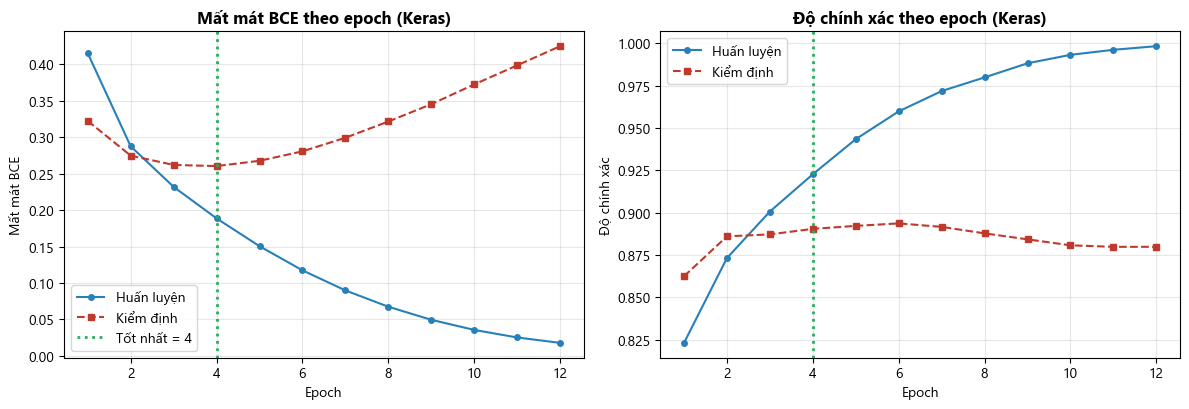

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ep = np.arange(1, EPOCHS + 1)
axes[0].plot(ep, history["train_loss"], "o-", color="#2980b9", label="Huấn luyện", markersize=4)
axes[0].plot(ep, history["val_loss"], "s--", color="#c0392b", label="Kiểm định", markersize=4)
axes[0].axvline(best_epoch, color="#27ae60", linestyle=":", lw=2, label=f"Tốt nhất = {best_epoch}")
axes[0].set_title("Mất mát BCE theo epoch (Keras)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Mất mát BCE")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["train_acc"], "o-", color="#2980b9", label="Huấn luyện", markersize=4)
axes[1].plot(ep, history["val_acc"], "s--", color="#c0392b", label="Kiểm định", markersize=4)
axes[1].axvline(best_epoch, color="#27ae60", linestyle=":", lw=2)
axes[1].set_title("Độ chính xác theo epoch (Keras)", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Độ chính xác")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Diễn giải hình.** Bảng bên trái cho thấy đáy của đường mất mát kiểm định tại epoch 4 rất nông: giá
trị tại epoch 3, 4 và 5 lần lượt là 0.2620, 0.2604 và 0.2677, chênh nhau chưa tới 0.008. Điều này
khẳng định nhận định ở phần trên rằng việc chọn epoch 4 thay vì epoch 3 không phải một khác biệt có ý
nghĩa mà chỉ là dao động nhỏ quanh cùng một điểm tối ưu.

Bảng bên phải bổ sung thông tin quan trọng: độ chính xác kiểm định đạt đỉnh **0.8937 tại epoch 6**,
muộn hơn hai epoch so với đáy của mất mát, rồi mới suy giảm dần về 0.8799. Khoảng cách hai epoch giữa
hai tiêu chí là bằng chứng trực quan cho thấy `val_loss` và `val_acc` không phải hai cách đo cùng một
thứ. Trong khoảng epoch 4 tới 6, mô hình vẫn đang cải thiện khả năng xếp đúng phía của ngưỡng trong
khi đã bắt đầu mất khả năng hiệu chuẩn xác suất.

Nếu báo cáo chọn epoch theo `val_acc`, mô hình cuối cùng sẽ là epoch 6 với accuracy kiểm định 0.8937
thay vì 0.8905 của epoch 4. Báo cáo vẫn giữ tiêu chí `val_loss` vì ba lý do: nó nhất quán với hai
notebook còn lại, nó là tiêu chí khắt khe hơn, và nó cho mô hình có xác suất được hiệu chuẩn tốt hơn,
điều thực sự quan trọng nếu sau này muốn hiệu chỉnh ngưỡng cho lớp thiểu số.

## 7. Lưu mô hình và kết quả trung gian

Tệp `_partial_tensorflow.json` là đầu vào thứ ba cho phần tổng hợp ở notebook 01, nơi ba hình so
sánh và tệp `metrics_customer_comments.json` được dựng.

In [7]:
model.save("../models/comments_cnn_tensorflow.keras")
print("Đã lưu mô hình:", "../models/comments_cnn_tensorflow.keras")

partial_tf = {
    "framework": "TensorFlow/Keras",
    "params": int(N_PARAMS),
    "train_time_s": float(TRAIN_TIME),
    "epochs": int(EPOCHS),
    "best_epoch": int(best_epoch),
    **tf_metrics,
    "history": history,
    "confusion_matrix": cm_tf.tolist(),
    "dataset": {"file": "womens_ecommerce_reviews.csv", "n_raw": int(N_RAW),
                "n_clean": int(N_CLEAN), "n_train": int(N_TRAIN),
                "n_val": int(N_VAL), "n_test": int(N_TEST), "n_features": int(MAX_LEN)},
}
with open(f"{REPORT_DIR}/_partial_tensorflow.json", "w", encoding="utf-8") as f:
    json.dump(partial_tf, f, ensure_ascii=False, indent=2)
print("Đã ghi:", f"{REPORT_DIR}/_partial_tensorflow.json")
print(json.dumps({k: v for k, v in partial_tf.items()
                  if k not in ("history", "dataset")}, indent=2, ensure_ascii=False))

Đã lưu mô hình: ../models/comments_cnn_tensorflow.keras
Đã ghi: ../reports/_partial_tensorflow.json
{
  "framework": "TensorFlow/Keras",
  "params": 509665,
  "train_time_s": 21.278382301330566,
  "epochs": 12,
  "best_epoch": 4,
  "accuracy": 0.8781277597880482,
  "precision": 0.9088397790055248,
  "recall": 0.9460819554277499,
  "f1": 0.9270870024656569,
  "roc_auc": 0.9057559339072903,
  "loss": 0.2873860812710581,
  "confusion_matrix": [
    [
      351,
      264
    ],
    [
      150,
      2632
    ]
  ]
}


---

## 8. Kết luận notebook 03

Notebook đã hoàn tất cách hiện thực thứ ba và khép lại bộ ba của miền `customer_comments`.

**Về đối chứng.** Keras cho đúng 509 665 tham số, trùng khớp với NumPy thuần và PyTorch. Accuracy đạt
0.8781, nằm trong biên độ 0.50 điểm phần trăm so với hai hiện thực kia; ROC AUC đạt 0.9058, thực tế
cao hơn PyTorch. Ba framework vì vậy tương đương về mặt thống kê, và sự tương đương này là bằng chứng
gián tiếp cuối cùng cho thấy hiện thực NumPy thuần tự viết đạo hàm ở notebook 01 là chính xác.

**Về khác biệt quy ước.** Hai điểm cần ghi nhớ khi đọc chéo mã nguồn giữa Keras và PyTorch. Thứ nhất,
Keras dùng bố cục `(batch, vị trí, kênh)` nên đầu ra `Embedding` nối thẳng vào `Conv1D` mà không cần
hoán vị trục, trong khi PyTorch bắt buộc phải có `transpose(1,2)`. Thứ hai, Keras không cung cấp tham
số tương đương `padding_idx`, nên hàng `<PAD>` vẫn là tham số học được. Sai lệch thứ hai đã được ghi
rõ trong khóa `notes` của tệp metrics; ảnh hưởng thực tế của nó bị giới hạn bởi tầng
`GlobalMaxPooling1D` vốn chỉ cho một vị trí đi tiếp, và bằng chứng thực nghiệm là chỉ số cuối cùng
không lệch khỏi hai hiện thực kia quá nửa điểm phần trăm.

**Về giá của sự trừu tượng hóa.** Notebook này ngắn nhất trong ba notebook và chứa ít mã nhất, nhưng
đó chính là điều đáng suy nghĩ: toàn bộ vòng huấn luyện, cơ chế dừng sớm và việc tính đạo hàm được
thu gọn vào `model.fit` cùng một callback. Sự tiện lợi đó rất có giá trị trong thực tiễn, nhưng nó
cũng khiến mọi chi tiết ở Mục 6 của notebook 01 trở nên vô hình. Bộ ba notebook được thiết kế theo
thứ tự trừu tượng hóa tăng dần chính là để giữ lại phần hiểu biết mà sự tiện lợi có xu hướng che lấp.

Kết quả đã được ghi vào `reports/_partial_tensorflow.json`. Phần tổng hợp ba framework, ba hình so
sánh và tệp `metrics_customer_comments.json` nằm ở cuối notebook 01, notebook được chạy sau cùng
trong chuỗi.